In [1]:
from pathlib import Path
import json
import matplotlib.pyplot as plt
import pandas as pd

from utils import parse_latencies_trt, parse_power_log, get_power_index, compute_layer_metrics_by_cycle

In [2]:
DATA_PATH = Path('../raw_data/single_conv_layer_trt')

In [3]:
with open((DATA_PATH/'idling_power.json'), 'r') as fp:
    data = json.load(fp)

avg_power = data['avg_idle_power']
print(f'Average power consumed in IDLE state: {avg_power}')

Average power consumed in IDLE state: 3576245.017657479


## Single Convolution Layers


### Kernel 1 Stride 1 Output 3

In [4]:
model_name = 'conv_k1_s1_o3'

with open((DATA_PATH/model_name/f'{model_name}_power_log.log'), 'r') as fp:
    data = fp.readlines()
power_data = parse_power_log(data)

with open((DATA_PATH/model_name/'trt_profiling/trt_layer_latency.json'), 'r') as fp:
    data = json.load(fp)
latency_data = parse_latencies_trt(data)

Preprocessing latency data: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 72.26it/s]


In [5]:
print(f"Number of power entries for {model_name}: {len(power_data)}")
print(f"Number of TensorRT layers in {model_name}: {len(latency_data[0])}")
print(f"Number of latency entries for each layer: {len(latency_data)}")
print(f"Inference for {len(latency_data)} cycles: {(latency_data[len(latency_data)-1][0][2]-latency_data[0][0][1]).total_seconds()} seconds")

Number of power entries for conv_k1_s1_o3: 17278
Number of TensorRT layers in conv_k1_s1_o3: 1
Number of latency entries for each layer: 3000
Inference for 3000 cycles: 3.771303 seconds


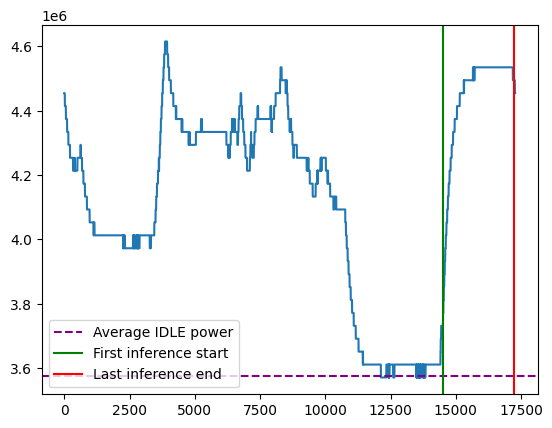

In [6]:
plt.plot([power for (_, power) in power_data])
plt.axhline(avg_power, color='purple', linestyle='--', label='Average IDLE power')
first_inference_start_index = get_power_index(power_data, latency_data[0][0][1])
last_inference_end_index = get_power_index(power_data, latency_data[len(latency_data)-1][0][2])
plt.axvline(first_inference_start_index, color='green', label='First inference start')
plt.axvline(last_inference_end_index, color='red', label='Last inference end')
plt.legend()

In [7]:
metrics = compute_layer_metrics_by_cycle(power_data, latency_data, avg_power)
metrics_df_k1 = pd.DataFrame.from_dict(metrics)

Computing layer metrics...


Mapping power to layer: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3000/3000 [00:00<00:00, 1664846.78it/s]


In [8]:
metrics_df_k1.describe()

,cycle,layer_power_including_idle_power_micro_watt,layer_power_excluding_idle_power_micro_watt,layer_run_time
count,3000.000000,5.880000e+02,588.000000,3000.000000
mean,1500.500000,4.461032e+06,884787.472138,0.273359
std,866.169729,1.485564e+05,148556.378890,0.053302
min,1.000000,3.731904e+06,155658.982343,0.251808
25%,750.750000,4.494336e+06,918090.982343,0.274720
50%,1500.500000,4.534464e+06,958218.982343,0.275648
75%,2250.250000,4.534464e+06,958218.982343,0.276352
max,3000.000000,4.534464e+06,958218.982343,2.946720


In [9]:
metrics_df_k1.count()

cycle                                          3000
layer_power_including_idle_power_micro_watt     588
layer_power_excluding_idle_power_micro_watt     588
layer_run_time                                 3000
dtype: int64

<Axes: >

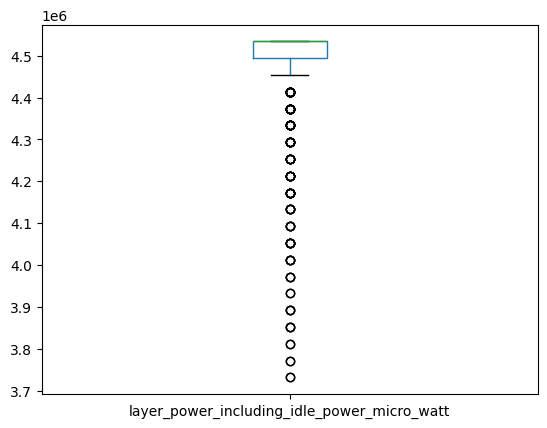

In [10]:
metrics_df_k1.boxplot(column='layer_power_including_idle_power_micro_watt', grid=False)

### Kernel 2 Stride 1 Output 3

In [11]:
model_name = 'conv_k2_s1_o3'

with open((DATA_PATH/model_name/f'{model_name}_power_log.log'), 'r') as fp:
    data = fp.readlines()
power_data = parse_power_log(data)

with open((DATA_PATH/model_name/'trt_profiling/trt_layer_latency.json'), 'r') as fp:
    data = json.load(fp)
latency_data = parse_latencies_trt(data)

Preprocessing latency data: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 72.01it/s]


In [12]:
print(f"Number of power entries for {model_name}: {len(power_data)}")
print(f"Number of TensorRT layers in {model_name}: {len(latency_data[0])}")
print(f"Number of latency entries for each layer: {len(latency_data)}")
print(f"Inference for {len(latency_data)} cycles: {(latency_data[len(latency_data)-1][0][2]-latency_data[0][0][1]).total_seconds()} seconds")

Number of power entries for conv_k2_s1_o3: 15522
Number of TensorRT layers in conv_k2_s1_o3: 1
Number of latency entries for each layer: 3000
Inference for 3000 cycles: 3.797045 seconds


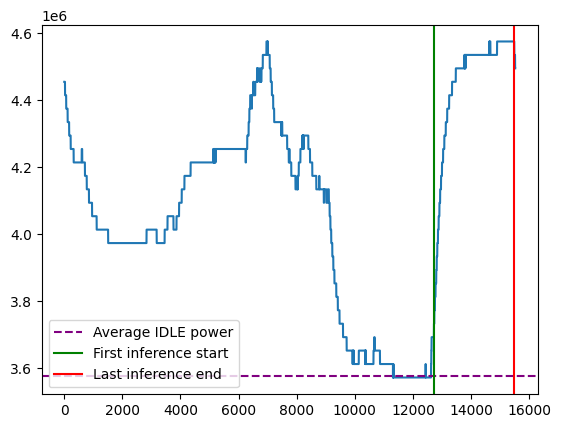

In [13]:
plt.plot([power for (_, power) in power_data])
plt.axhline(avg_power, color='purple', linestyle='--', label='Average IDLE power')
first_inference_start_index = get_power_index(power_data, latency_data[0][0][1])
last_inference_end_index = get_power_index(power_data, latency_data[len(latency_data)-1][0][2])
plt.axvline(first_inference_start_index, color='green', label='First inference start')
plt.axvline(last_inference_end_index, color='red', label='Last inference end')
plt.legend()

In [14]:
metrics = compute_layer_metrics_by_cycle(power_data, latency_data, avg_power)
metrics_df_k2 = pd.DataFrame.from_dict(metrics)

Computing layer metrics...


Mapping power to layer: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3000/3000 [00:00<00:00, 1460073.33it/s]


In [15]:
metrics_df_k2.describe()

,cycle,layer_power_including_idle_power_micro_watt,layer_power_excluding_idle_power_micro_watt,layer_run_time
count,3000.000000,7.770000e+02,777.000000,3000.000000
mean,1500.500000,4.460147e+06,883902.132922,0.350930
std,866.169729,1.739263e+05,173926.324933,0.005246
min,1.000000,3.691776e+06,115530.982343,0.324928
25%,750.750000,4.454208e+06,877962.982343,0.350368
50%,1500.500000,4.534464e+06,958218.982343,0.351168
75%,2250.250000,4.534464e+06,958218.982343,0.351968
max,3000.000000,4.574592e+06,998346.982343,0.426112


In [16]:
metrics_df_k2.count()

cycle                                          3000
layer_power_including_idle_power_micro_watt     777
layer_power_excluding_idle_power_micro_watt     777
layer_run_time                                 3000
dtype: int64

<Axes: >

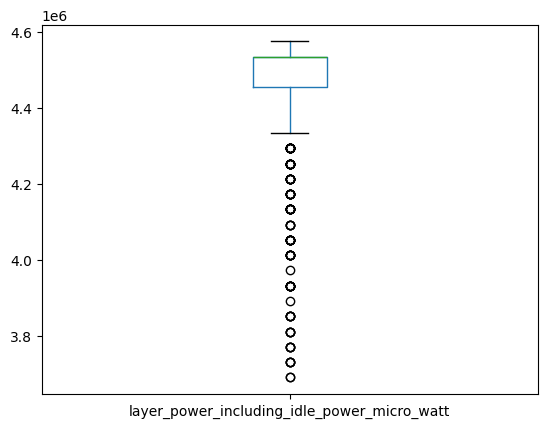

In [17]:
metrics_df_k2.boxplot(column='layer_power_including_idle_power_micro_watt', grid=False)

### Kernel 3 Stride 1 Output 3

In [18]:
model_name = 'conv_k3_s1_o3'

with open((DATA_PATH/model_name/f'{model_name}_power_log.log'), 'r') as fp:
    data = fp.readlines()
power_data = parse_power_log(data)

with open((DATA_PATH/model_name/'trt_profiling/trt_layer_latency.json'), 'r') as fp:
    data = json.load(fp)
latency_data = parse_latencies_trt(data)

Preprocessing latency data: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3/3 [00:00<00:00, 79.76it/s]


In [19]:
print(f"Number of power entries for {model_name}: {len(power_data)}")
print(f"Number of TensorRT layers in {model_name}: {len(latency_data[0])}")
print(f"Number of latency entries for each layer: {len(latency_data)}")
print(f"Inference for {len(latency_data)} cycles: {(latency_data[len(latency_data)-1][0][2]-latency_data[0][0][1]).total_seconds()} seconds")

Number of power entries for conv_k3_s1_o3: 16724
Number of TensorRT layers in conv_k3_s1_o3: 3
Number of latency entries for each layer: 3000
Inference for 3000 cycles: 4.139796 seconds


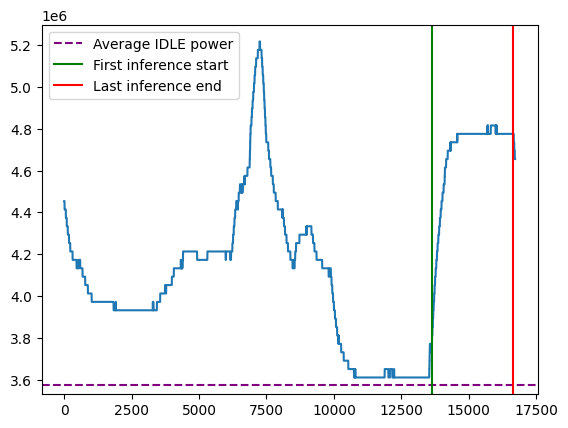

In [20]:
plt.plot([power for (_, power) in power_data])
plt.axhline(avg_power, color='purple', linestyle='--', label='Average IDLE power')
first_inference_start_index = get_power_index(power_data, latency_data[0][0][1])
last_inference_end_index = get_power_index(power_data, latency_data[len(latency_data)-1][0][2])
plt.axvline(first_inference_start_index, color='green', label='First inference start')
plt.axvline(last_inference_end_index, color='red', label='Last inference end')
plt.legend()

In [21]:
metrics = compute_layer_metrics_by_cycle(power_data, latency_data, avg_power)
metrics_df_k3 = pd.DataFrame.from_dict(metrics)

Computing layer metrics...


Mapping power to layer: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████| 9000/9000 [00:00<00:00, 1963523.33it/s]


In [22]:
metrics_df_k3.describe()

,cycle,layer_power_including_idle_power_micro_watt,layer_power_excluding_idle_power_micro_watt,layer_run_time
count,9000.000000,9.550000e+02,9.550000e+02,9000.000000
mean,1500.500000,4.687245e+06,1.111000e+06,0.154072
std,866.073472,2.059150e+05,2.059150e+05,0.059956
min,1.000000,3.772032e+06,1.957870e+05,0.081920
25%,750.750000,4.735104e+06,1.158859e+06,0.083200
50%,1500.500000,4.775232e+06,1.198987e+06,0.152000
75%,2250.250000,4.775232e+06,1.198987e+06,0.227680
max,3000.000000,4.815360e+06,1.239115e+06,0.354176


In [23]:
metrics_df_k3.count()

cycle                                          9000
layer_power_including_idle_power_micro_watt     955
layer_power_excluding_idle_power_micro_watt     955
layer_run_time                                 9000
dtype: int64

<Axes: >

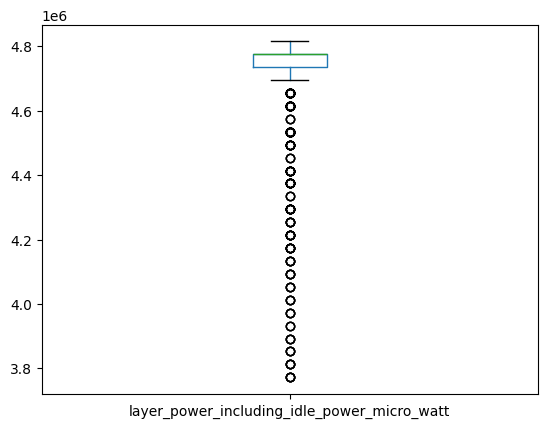

In [24]:
metrics_df_k3.boxplot(column='layer_power_including_idle_power_micro_watt', grid=False)

### Kernel 4 Stride 1 Output 3

In [25]:
model_name = 'conv_k4_s1_o3'

with open((DATA_PATH/model_name/f'{model_name}_power_log.log'), 'r') as fp:
    data = fp.readlines()
power_data = parse_power_log(data)

with open((DATA_PATH/model_name/'trt_profiling/trt_layer_latency.json'), 'r') as fp:
    data = json.load(fp)
latency_data = parse_latencies_trt(data)

Preprocessing latency data: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3/3 [00:00<00:00, 75.07it/s]


In [26]:
print(f"Number of power entries for {model_name}: {len(power_data)}")
print(f"Number of TensorRT layers in {model_name}: {len(latency_data[0])}")
print(f"Number of latency entries for each layer: {len(latency_data)}")
print(f"Inference for {len(latency_data)} cycles: {(latency_data[len(latency_data)-1][0][2]-latency_data[0][0][1]).total_seconds()} seconds")

Number of power entries for conv_k4_s1_o3: 16621
Number of TensorRT layers in conv_k4_s1_o3: 3
Number of latency entries for each layer: 3000
Inference for 3000 cycles: 4.498755 seconds


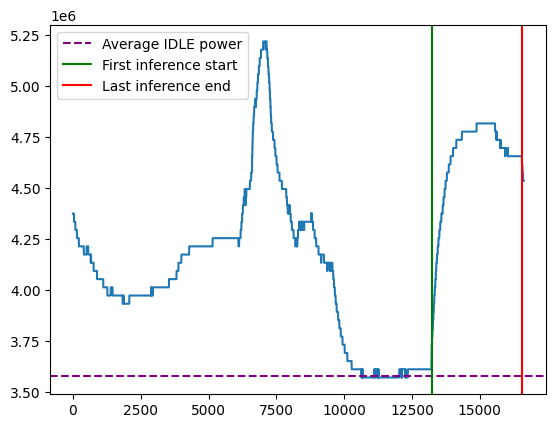

In [27]:
plt.plot([power for (_, power) in power_data])
plt.axhline(avg_power, color='purple', linestyle='--', label='Average IDLE power')
first_inference_start_index = get_power_index(power_data, latency_data[0][0][1])
last_inference_end_index = get_power_index(power_data, latency_data[len(latency_data)-1][0][2])
plt.axvline(first_inference_start_index, color='green', label='First inference start')
plt.axvline(last_inference_end_index, color='red', label='Last inference end')
plt.legend()

In [28]:
metrics = compute_layer_metrics_by_cycle(power_data, latency_data, avg_power)
metrics_df_k4 = pd.DataFrame.from_dict(metrics)

Computing layer metrics...


Mapping power to layer: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████| 9000/9000 [00:00<00:00, 1639467.36it/s]


In [29]:
metrics_df_k4.describe()

,cycle,layer_power_including_idle_power_micro_watt,layer_power_excluding_idle_power_micro_watt,layer_run_time
count,9000.000000,8.090000e+02,8.090000e+02,9000.000000
mean,1500.500000,4.669084e+06,1.092839e+06,0.155649
std,866.073472,1.890895e+05,1.890895e+05,0.068940
min,1.000000,3.772032e+06,1.957870e+05,0.079808
25%,750.750000,4.654848e+06,1.078603e+06,0.081312
50%,1500.500000,4.694976e+06,1.118731e+06,0.152544
75%,2250.250000,4.775232e+06,1.198987e+06,0.231296
max,3000.000000,4.815360e+06,1.239115e+06,2.817216


In [30]:
metrics_df_k4.count()

cycle                                          9000
layer_power_including_idle_power_micro_watt     809
layer_power_excluding_idle_power_micro_watt     809
layer_run_time                                 9000
dtype: int64

<Axes: >

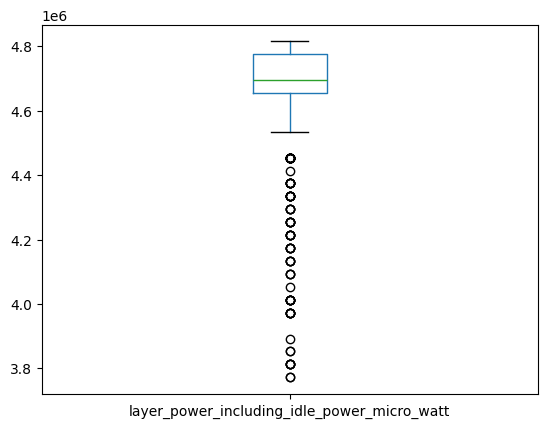

In [31]:
metrics_df_k4.boxplot(column='layer_power_including_idle_power_micro_watt', grid=False)

### Kernel 5 Stride 1 Output 3

In [32]:
model_name = 'conv_k5_s1_o3'

with open((DATA_PATH/model_name/f'{model_name}_power_log.log'), 'r') as fp:
    data = fp.readlines()
power_data = parse_power_log(data)

with open((DATA_PATH/model_name/'trt_profiling/trt_layer_latency.json'), 'r') as fp:
    data = json.load(fp)
latency_data = parse_latencies_trt(data)

Preprocessing latency data: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3/3 [00:00<00:00, 34.48it/s]


In [33]:
print(f"Number of power entries for {model_name}: {len(power_data)}")
print(f"Number of TensorRT layers in {model_name}: {len(latency_data[0])}")
print(f"Number of latency entries for each layer: {len(latency_data)}")
print(f"Inference for {len(latency_data)} cycles: {(latency_data[len(latency_data)-1][0][2]-latency_data[0][0][1]).total_seconds()} seconds")

Number of power entries for conv_k5_s1_o3: 17380
Number of TensorRT layers in conv_k5_s1_o3: 3
Number of latency entries for each layer: 3000
Inference for 3000 cycles: 4.651095 seconds


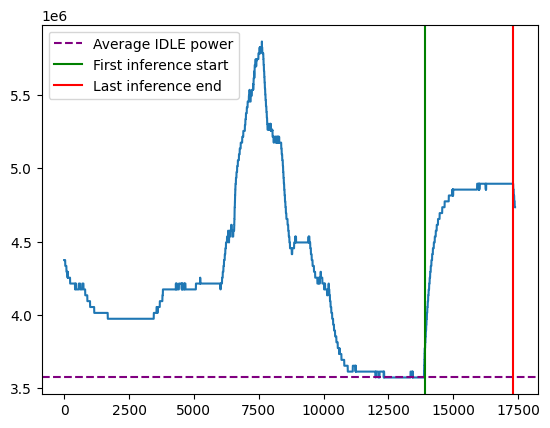

In [34]:
plt.plot([power for (_, power) in power_data])
plt.axhline(avg_power, color='purple', linestyle='--', label='Average IDLE power')
first_inference_start_index = get_power_index(power_data, latency_data[0][0][1])
last_inference_end_index = get_power_index(power_data, latency_data[len(latency_data)-1][0][2])
plt.axvline(first_inference_start_index, color='green', label='First inference start')
plt.axvline(last_inference_end_index, color='red', label='Last inference end')
plt.legend()

In [35]:
metrics = compute_layer_metrics_by_cycle(power_data, latency_data, avg_power)
metrics_df_k5 = pd.DataFrame.from_dict(metrics)

Computing layer metrics...


Mapping power to layer: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████| 9000/9000 [00:00<00:00, 1491455.39it/s]


In [36]:
metrics_df_k5.describe()

,cycle,layer_power_including_idle_power_micro_watt,layer_power_excluding_idle_power_micro_watt,layer_run_time
count,9000.000000,1.302000e+03,1.302000e+03,9000.000000
mean,1500.500000,4.790858e+06,1.214613e+06,0.200675
std,866.073472,1.971570e+05,1.971570e+05,0.125470
min,1.000000,3.772032e+06,1.957870e+05,0.079296
25%,750.750000,4.815360e+06,1.239115e+06,0.081568
50%,1500.500000,4.855488e+06,1.279243e+06,0.151680
75%,2250.250000,4.895616e+06,1.319371e+06,0.372832
max,3000.000000,4.895616e+06,1.319371e+06,0.377056


In [37]:
metrics_df_k5.count()

cycle                                          9000
layer_power_including_idle_power_micro_watt    1302
layer_power_excluding_idle_power_micro_watt    1302
layer_run_time                                 9000
dtype: int64

<Axes: >

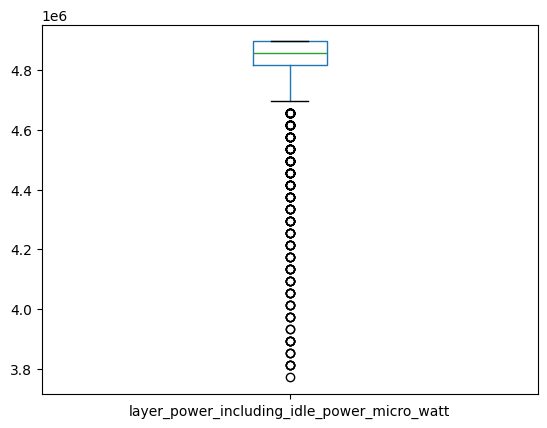

In [38]:
metrics_df_k5.boxplot(column='layer_power_including_idle_power_micro_watt', grid=False)

## Kernels Plot

Text(0.5, 0, 'Kernel size')

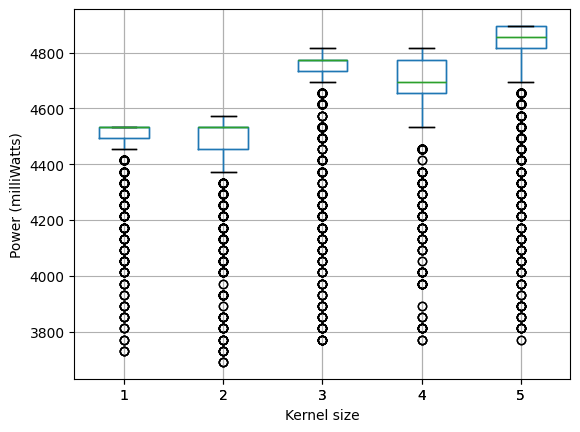

In [39]:
df = pd.concat(
    [
        metrics_df_k1["layer_power_including_idle_power_micro_watt"] * 1e-3,
        metrics_df_k2["layer_power_including_idle_power_micro_watt"] * 1e-3,
        metrics_df_k3["layer_power_including_idle_power_micro_watt"] * 1e-3,
        metrics_df_k4["layer_power_including_idle_power_micro_watt"] * 1e-3,
        metrics_df_k5["layer_power_including_idle_power_micro_watt"] * 1e-3,
    ],
    axis=1,
)


# set column names (will be displayed as plot labels)
df.columns = ['1', '2', '3', '4', '5']  

# use pandas' boxplot method
df.boxplot().set_ylabel('Power (milliWatts)')
df.boxplot().set_xlabel('Kernel size')